In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Dataset is pretty big but if theres issues get rid of this parameter
df = pd.read_csv("ipl_matches_2020_2025.csv", low_memory=False)

In [ ]:
# dirty up the data, since our dataset is already clean
# seed allows for same outcome each time
np.random.seed(42)

# allows us to add "nan" values to column of our choosing
def dirty_col(df, name, range):
  dirtied = np.random.rand(len(df)) < range
  df.loc[dirtied, name] = np.nan

# time to dirty the columns
dirty_col(df, "match_id", 0.05)
dirty_col(df, "date", 0.05)
dirty_col(df, "batting_team", 0.10)
dirty_col(df, "bowling_team", 0.10)
dirty_col(df, "city", 0.08)
dirty_col(df, "runs_batter", 0.08)

df.to_csv("ipl_matches_dirty.csv", index = False)

print("Data is now dirty")
print(df[['match_id', 'date', 'batting_team', 'bowling_team', 'city', 'runs_batter']].isnull().sum())

Data is now dirty
match_id        4924
date            4844
batting_team    9982
bowling_team    9963
city            7898
runs_batter     7903
dtype: int64


In [ ]:
# time to clean the data now
df_cleaned = pd.read_csv("ipl_matches_dirty.csv", low_memory=False)

# after looking at the data we see that the columns of
# date, match_id, battting and bowling team typically have same values in front of it
# so using the data that is in front for behind will be a good way to fill it,
# this way we keep ball data, and don't have to dropna
df_cleaned["date"] = df_cleaned["date"].ffill().bfill()
df_cleaned["match_id"] = df_cleaned["match_id"].ffill().bfill()
df_cleaned["batting_team"] = df_cleaned["batting_team"].ffill().bfill()
df_cleaned["bowling_team"] = df_cleaned["bowling_team"].ffill().bfill()
df_cleaned["city"] = df_cleaned["city"].ffill().bfill()



In [ ]:
# now we see how everyting is almost clean now, all we have to do is get the batters run now
print(df_cleaned[['match_id', 'date', 'batting_team', 'bowling_team', 'city', 'runs_batter']].isnull().sum())

match_id           0
date               0
batting_team       0
bowling_team       0
city               0
runs_batter     7903
dtype: int64


In [ ]:
# for the runs_batter we can fill it in with the mode
# to make it more accurate we can take the mode of that specific over that they are in
# since typically if a batter is hitting alot of boundries they continue to do so
# however if a batter is out in that ball, then their runs will be 0

# if player_out isn't null then someone got out, so we must make the runs for that ball a 0
check_if_out = df_cleaned["runs_batter"].isnull() & df_cleaned["player_out"].notnull()
df_cleaned.loc[check_if_out, 'runs_batter'] = 0

print(f"Filled {check_if_out.sum()}")

Filled 400


In [ ]:
# fill in the rest of the balls with the mode of that over
def fill_mode(over):
  mode = over.mode()
  if not mode.empty:
    return over.fillna(mode.iloc[0])
  else:
    return over.fillna(0)

df_cleaned['runs_batter'] = df_cleaned.groupby(['match_id', 'innings', 'over'])['runs_batter'].transform(fill_mode)
# in the print we see that there is not null value, that means everything was filled in correctly.
print(f"{df_cleaned['runs_batter'].isnull().sum()}")

0


In [ ]:
# time to parse the data now
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
df_cleaned['season'] = pd.to_numeric(df_cleaned['season'].astype(str).str.split('/').str[0], errors='coerce').astype('Int64')

In [ ]:
# The Correct F-String Syntax:
print(f"Date Col Type: {df_cleaned['date'].dtype}")
print(f"Season Col Type: {df_cleaned['season'].dtype}")

# we see in the output that the date is now in datetime
# the season is in int64 now, since it represented years

Date Col Type: datetime64[ns]
Season Col Type: Int64


In [ ]:
df_cleaned.loc[df_cleaned['city'] == 'Unknown', 'city'] = np.nan
df_cleaned.loc[df_cleaned['stage'] == 'Unknown', 'stage'] = np.nan
df_cleaned.loc[df_cleaned['match_number'] == 'Unknown', 'match_number'] = np.nan

# fill city using venue with ffill() and bfill()
df_cleaned['city'] = df_cleaned.groupby('venue')['city'].ffill().bfill()

In [ ]:
# it is time to now organize the dataset, we will be organizing it into specific groups that will be useful for hypothese testing

#this tells us the summary of the match, gets rid of the need to look at unnessecay data
df_match = df_cleaned[['match_id', 'date', 'match_type', 'event_name', 'venue', 'city',
    'day', 'month', 'year', 'season', 'gender', 'team_type',
    'toss_winner', 'toss_decision', 'match_won_by', 'win_outcome',
    'player_of_match', 'result_type', 'method', 'superover_winner',
    'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number']]
# get rid of all the extra "match_id" there are
df_match = df_match.drop_duplicates(subset='match_id')

# info about balls bowled
df_balls = df_cleaned[['match_id', 'innings', 'batting_team', 'bowling_team', 'over', 'ball',
    'ball_no', 'batter', 'bowler', 'runs_batter', 'balls_faced',
    'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler',
    'runs_not_boundary', 'extra_type', 'non_striker',
    'wicket_kind', 'player_out', 'fielders', 'striker_out']]

# info about the batters
df_batter = df_cleaned[['match_id', 'innings', 'batter', 'bat_pos', 'batting_team',
    'runs_batter', 'balls_faced', 'batter_runs', 'batter_balls']]

# info about the bowlers
df_bowler = df_cleaned[['match_id', 'innings', 'bowler', 'bowling_team',
    'runs_bowler', 'valid_ball', 'bowler_wicket']]

# info about the teams
df_team_innings = df_cleaned[['match_id', 'innings', 'batting_team', 'bowling_team',
    'team_runs', 'team_balls', 'team_wicket', 'runs_target',
    'runs_total', 'runs_extras', 'valid_ball']]

In [ ]:
print("match df")
print(df_match.head())

print("ball df")
print(df_balls.head())

print("batter df:")
print(df_batter.head())

print("bowler df:")
print(df_bowler.head())

print("team inning df:")
print(df_team_innings.head())

match df
      match_id       date match_type             event_name  \
0    1216492.0 2020-09-19        T20  Indian Premier League   
245  1216493.0 2020-09-20        T20  Indian Premier League   
500  1216534.0 2020-09-21        T20  Indian Premier League   
746  1216496.0 2020-09-22        T20  Indian Premier League   
998  1216508.0 2020-09-23        T20  Indian Premier League   

                                   venue       city  day  month  year  season  \
0                   Sheikh Zayed Stadium  Abu Dhabi   19      9  2020    2020   
245  Dubai International Cricket Stadium  Abu Dhabi   20      9  2020    2020   
500  Dubai International Cricket Stadium  Abu Dhabi   21      9  2020    2020   
746              Sharjah Cricket Stadium  Abu Dhabi   22      9  2020    2020   
998                 Sheikh Zayed Stadium  Abu Dhabi   23      9  2020    2020   

     ... win_outcome player_of_match result_type method superover_winner  \
0    ...   5 wickets       AT Rayudu         NaN 

In [ ]:
# Aggregating data before running tests on it
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Aggregate the ball-by-ball data
innings_data = df_balls.groupby(['match_id', 'innings']).agg(
    total_runs=('runs_total', 'sum'),
    wickets_lost=('player_out', 'count')
).reset_index()

innings_data = innings_data.merge(df_match[['match_id', 'season']], on='match_id', how='left')
first_innings = innings_data[innings_data['innings'] == 1].dropna(subset=['season'])

### Method 1: Central Tendency and Variance
**Objective:** Understand the baseline characteristics and spread of first-innings scores in the IPL.

**Statistical Approach:** We will calculate the fundamental descriptive statistics of our dataset: the **Mean**, **Median**, and **Standard Deviation ($\sigma$)**.
* The relationship between the mean and median will tell us if the data is skewed.
* The standard deviation will quantify the variance (how spread out the scores are from the average).

We will visualize this using a classic frequency histogram, plotting the central tendency and showing the bounds of one standard deviation to see where the vast majority of normal cricket matches conclude.

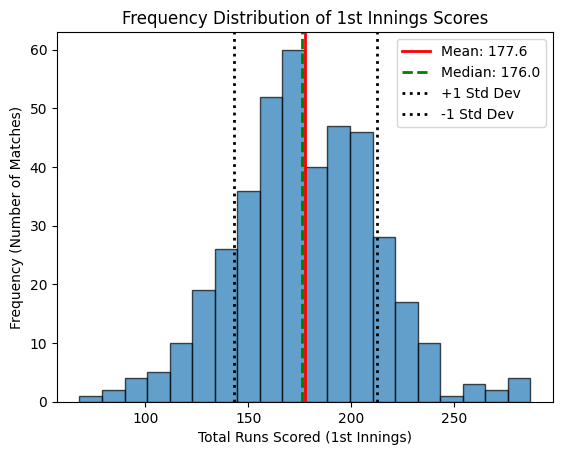

In [ ]:
plt.figure()

# Calculate stats
mean_score = first_innings['total_runs'].mean()
median_score = first_innings['total_runs'].median()
std_dev = first_innings['total_runs'].std()

# Standard matplotlib histogram
plt.hist(first_innings['total_runs'], bins=20, edgecolor='black', alpha=0.7)

# Plot reference lines
plt.axvline(mean_score, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_score:.1f}')
plt.axvline(median_score, color='green', linestyle='--', linewidth=2, label=f'Median: {median_score:.1f}')
plt.axvline(mean_score + std_dev, color='black', linestyle=':', linewidth=2, label='+1 Std Dev')
plt.axvline(mean_score - std_dev, color='black', linestyle=':', linewidth=2, label='-1 Std Dev')

plt.title('Frequency Distribution of 1st Innings Scores')
plt.xlabel('Total Runs Scored (1st Innings)')
plt.ylabel('Frequency (Number of Matches)')
plt.legend()
plt.show()

**Conclusion 1:** The **Mean (177.6 runs)** and the **Median (176.0 runs)** are nearly identical, indicating that our data is highly symmetric and normally distributed. The **Standard Deviation is 32.7 runs**. By plotting the $\sigma$ boundaries on our histogram, we can visually confirm that the vast majority of IPL teams batting first will score within the typical window of roughly **145 to 210 runs**. Anything below 145 represents a statistical underperformance, while crossing 210 is an exceptional batting display.

### Method 2: Correlation and Linear Regression
**Objective:** Determine if there is a quantifiable, statistically significant relationship between the number of wickets a team loses and their final total score in the first innings.

**Statistical Approach:** We will calculate the **Pearson Correlation Coefficient ($r$)**, which measures the linear correlation between two sets of data. The coefficient ranges from -1 to 1, where -1 is a perfect negative linear correlation, 0 is no correlation, and 1 is a perfect positive correlation. Alongside the Pearson $r$, we will calculate the **p-value** to formally test our hypotheses with a standard alpha value of 0.05:

* **Null Hypothesis ($H_0$):** There is no linear correlation between the number of wickets lost and the final score ($r = 0$).
* **Alternative Hypothesis ($H_A$):** There is a statistically significant linear correlation between the two variables ($r \neq 0$).

Finally, we will plot a standard scatter plot with a line of best fit to visually demonstrate the trend and variance.

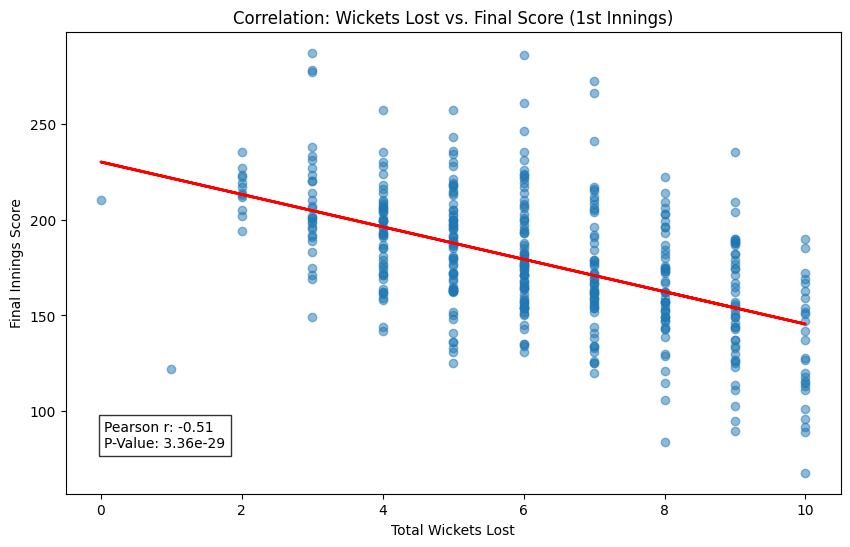

In [ ]:
plt.figure(figsize=(10, 6))

x = first_innings['wickets_lost']
y = first_innings['total_runs']

# Standard scatter plot
plt.scatter(x, y, alpha=0.5)

# Calculate and plot line of best fit (y = mx + b)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Calculate stats
correlation, p_val = stats.pearsonr(x, y)

plt.title('Correlation: Wickets Lost vs. Final Score (1st Innings)')
plt.xlabel('Total Wickets Lost')
plt.ylabel('Final Innings Score')

# Annotate stats on plot
plt.text(0.05, 0.1, f'Pearson r: {correlation:.2f}\nP-Value: {p_val:.2e}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

plt.show()

**Conclusion 2:** Using the Pearson Correlation Coefficient, we identified a statistically significant negative correlation (**r = -0.51**, p < 0.001) between wickets lost and the final score. Because the p-value is practically zero (3.36e-29), we can definitively conclude this relationship is not due to random chance and we can reject the null hypothesis. The line of best fit plotted above demonstrates that for every additional wicket lost, the expected total score drops sharply, mathematically proving the value of wicket preservation in T20 cricket.

### Method 3: Hypothesis Testing (Independent Two-Sample T-Test)
**Objective:** Cricket fans often debate whether batting first or fielding first provides an inherent advantage. We will statistically test if the innings order actually affects run production.

**Statistical Approach:** We will conduct an **Independent Two-Sample T-Test**. We are specifically using Welch's t-test because we cannot assume the variance between 1st innings scores and 2nd innings scores are perfectly equal.
* **Null Hypothesis ($H_0$):** There is no difference in the true mean score between the 1st innings and the 2nd innings ($\mu_1 = \mu_2$).
* **Alternative Hypothesis ($H_A$):** There is a difference in the true mean score between the 1st innings and the 2nd innings ($\mu_1 \neq \mu_2$).

We will evaluate the resulting **p-value** at a standard alpha level of 0.05 to determine if we can reject the null hypothesis, and visualize the two populations using overlapping density distributions.

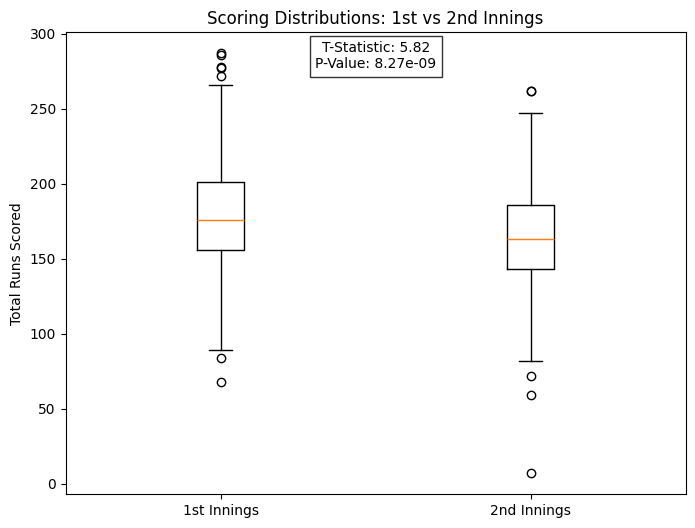

In [ ]:
# Separate innings totals
in_1_scores = innings_data[innings_data['innings'] == 1]['total_runs'].dropna()
in_2_scores = innings_data[innings_data['innings'] == 2]['total_runs'].dropna()

# Perform the T-Test
t_stat, p_value = stats.ttest_ind(in_1_scores, in_2_scores, equal_var=False)

plt.figure(figsize=(8, 6))

# Standard Matplotlib Boxplot
plt.boxplot([in_1_scores, in_2_scores], labels=['1st Innings', '2nd Innings'])

plt.title('Scoring Distributions: 1st vs 2nd Innings')
plt.ylabel('Total Runs Scored')

# Annotate stats
plt.text(1.5, in_1_scores.max() - 10, f"T-Statistic: {t_stat:.2f}\nP-Value: {p_value:.2e}",
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8),
         horizontalalignment='center')

plt.show()

**Conclusion 3:** We conducted a Welch's t-test to compare means between innings with the $H_0$ being that there is no difference in the mean score of the 1st and 2nd innings.

The test yielded a t-statistic of **5.82** and a p-value of **8.27e-09** which is much less than the alpha level of 0.05. Therefore, we can reject the null hypothesis. The boxplot confirms this visually: the median and entire interquartile range (the middle 50% of the data) of the first innings is visibly higher than the second innings. This proves a distinct statistical difference in run distributions, indicating that teams chasing a target generally score fewer runs on average. However, we can also note that this can be because the cap on the runs in the second inning will always be around the score of the first inning since the game is over once the initial run total is exceeded